<a href="https://colab.research.google.com/github/aaa020109-star/causal-inference-study/blob/main/01_dowhy_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DoWhy 기본 실습: 인과추론 4단계 파이프라인

**논문**: DoWhy: An End-to-End Library for Causal Inference (Sharma & Kiciman, 2020)

**학습 목표**: 논문의 4단계 파이프라인을 코드로 직접 실행해보기
- Step 1: Model (인과 그래프 정의)
- Step 2: Identify (인과 효과 식별)
- Step 3: Estimate (효과 추정)
- Step 4: Refute (추정 결과 반박 테스트)

## 0. 환경 설정

In [1]:
# 라이브러리 설치 (Colab에서 실행)
!pip install dowhy econml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 6.6 MB/s eta 0:00:00


In [2]:
import dowhy
from dowhy import CausalModel
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

print(f"DoWhy version: {dowhy.__version__}")

DoWhy version: 0.14


## 1. 데이터 준비

시나리오: **온라인 마케팅 캠페인의 인과적 효과 추정**
- Treatment: 마케팅 이메일 발송 여부 (v0)
- Outcome: 구매 금액 (y)
- Confounders: 과거 구매 횟수, 사이트 방문 빈도 등

먼저 DoWhy의 내장 데이터 생성기로 연습한 뒤, 나중에 Hillstrom 이메일 데이터셋으로 확장할 예정

In [4]:
# DoWhy 내장 데이터 생성 (선형 인과 모델)
from dowhy import datasets

data = datasets.linear_dataset(
    beta=5,           # 처치의 실제 인과 효과 (정답: 5)
    num_common_causes=3,   # 교란변수 개수
    num_instruments=1,     # 도구변수 개수
    num_samples=1000,
    treatment_is_binary=True
)

df = data["df"]
print("데이터 크기:", df.shape)
print("처음 5행:")
df.head()

데이터 크기: (1000, 6)
처음 5행:


,Z0,W0,W1,W2,v0,y
0,0.0,-2.528792,-0.451512,0.700402,False,-0.639589
1,1.0,-0.586806,-1.217444,-0.916808,True,3.552133
2,0.0,0.653218,-1.049607,-1.122514,True,3.994934
3,0.0,-0.331198,0.434586,0.136960,False,0.065026
4,0.0,1.292743,-0.744066,1.437514,True,6.963545


In [6]:
# 데이터 구조 확인
print("컬럼 설명:")
print("- v0: Treatment (처치, 이메일 발송 여부)")
print("- y: Outcome (결과, 구매 금액)")
print("- X0, X1, X2: Common Causes (교란변수)")
print("- Z0: Instrument (도구변수)")
print(f"실제 인과 효과 (beta): {data["ate"]:.4f}")

컬럼 설명:
- v0: Treatment (처치, 이메일 발송 여부)
- y: Outcome (결과, 구매 금액)
- X0, X1, X2: Common Causes (교란변수)
- Z0: Instrument (도구변수)
실제 인과 효과 (beta): 5.0000


## 2. Step 1: Model - 인과 그래프 정의

**논문 Section: "Model encodes prior knowledge as a formal causal graph"**

우리의 사전 지식(domain knowledge)을 인과 그래프로 표현합니다.
- 교란변수(X0, X1, X2)가 처치(v0)와 결과(y) 모두에 영향
- 도구변수(Z0)는 처치에만 영향 (결과에 직접 영향 X)

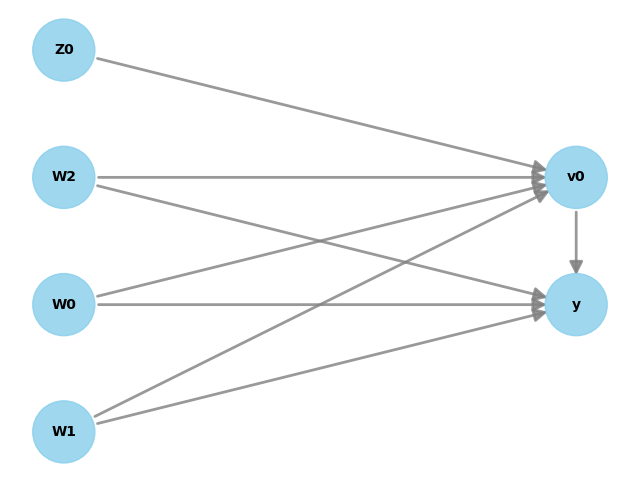

In [7]:
model = CausalModel(
    data=df,
    treatment=data["treatment_name"],       # v0
    outcome=data["outcome_name"],           # y
    common_causes=data["common_causes_names"],  # X0, X1, X2
    instruments=data["instrument_names"]    # Z0
)

# 인과 그래프 시각화
model.view_model()

**질문해보기**:
- 만약 교란변수를 하나 빼먹으면 어떻게 될까?
- 도구변수가 없으면 어떤 방법을 쓸 수 있을까?

## 3. Step 2: Identify - 인과 효과 식별

**논문 Section: "Identify uses graph-based methods to identify the causal effect"**

인과 그래프를 바탕으로, 관찰 데이터에서 인과 효과를 추정할 수 있는 수식(estimand)을 도출합니다.

In [8]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d                 
─────(E[y|W1,W0,W2])
d[v₀]               
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W0,W2,U) = P(y|v0,W1,W0,W2)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                      -1⎤
 ⎢  d      ⎛  d        ⎞  ⎥
E⎢─────(y)⋅⎜─────([v₀])⎟  ⎥
 ⎣d[Z₀]    ⎝d[Z₀]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0})
Estimand assumption 2, Exclusion: If we remove {Z0}→{v0}, then ¬({Z0}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d                 
─────(E[y|W1,W0,W2])
d[v₀]               
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W1,W0,W2,U) = P(y|v0,W1,W0,W2)



위 출력에서 "backdoor"와 "iv" 두 가지 식별 전략이 나옵니다:
- **Backdoor**: 교란변수를 조건부로 통제하여 인과 효과 추정
- **IV (Instrumental Variable)**: 도구변수를 활용하여 추정

이것이 Robins의 MSM 논문에서 다루는 "no unmeasured confounders" 가정과 연결됩니다.

## 4. Step 3: Estimate - 효과 추정

**논문 Section: "Estimate uses statistical methods for estimating the identified estimand"**

여러 가지 추정법을 비교해봅시다.

### 4-1. Propensity Score Matching (PSM)

In [9]:
estimate_psm = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching"
)
print("=== Propensity Score Matching ===")
print(f"추정된 인과 효과 (ATE): {estimate_psm.value:.4f}")
print(f"실제 인과 효과: {data["ate"]:.4f}")
print(f"오차: {abs(estimate_psm.value - data["ate"]):.4f}")

=== Propensity Score Matching ===
추정된 인과 효과 (ATE): 4.9362
실제 인과 효과: 5.0000
오차: 0.0637


### 4-2. Inverse Probability of Treatment Weighting (IPTW)

이것이 Robins의 MSM 논문의 핵심 방법론입니다!
각 관측치에 1/P(treatment|confounders) 가중치를 부여하여 가상의 무작위 배정 집단(pseudopopulation)을 생성합니다.

In [10]:
estimate_iptw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting"
)
print("=== IPTW (Inverse Probability Weighting) ===")
print(f"추정된 인과 효과 (ATE): {estimate_iptw.value:.4f}")
print(f"실제 인과 효과: {data["ate"]:.4f}")
print(f"오차: {abs(estimate_iptw.value - data["ate"]):.4f}")

=== IPTW (Inverse Probability Weighting) ===
추정된 인과 효과 (ATE): 5.0893
실제 인과 효과: 5.0000
오차: 0.0893


### 4-3. Linear Regression (회귀 분석)

In [11]:
estimate_lr = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print("=== Linear Regression ===")
print(f"추정된 인과 효과 (ATE): {estimate_lr.value:.4f}")
print(f"실제 인과 효과: {data["ate"]:.4f}")
print(f"오차: {abs(estimate_lr.value - data["ate"]):.4f}")

=== Linear Regression ===
추정된 인과 효과 (ATE): 4.9990
실제 인과 효과: 5.0000
오차: 0.0010


### 4-4. Instrumental Variable (IV) 추정

In [12]:
estimate_iv = model.estimate_effect(
    identified_estimand,
    method_name="iv.instrumental_variable"
)
print("=== Instrumental Variable ===")
print(f"추정된 인과 효과 (ATE): {estimate_iv.value:.4f}")
print(f"실제 인과 효과: {data["ate"]:.4f}")
print(f"오차: {abs(estimate_iv.value - data["ate"]):.4f}")

=== Instrumental Variable ===
추정된 인과 효과 (ATE): 5.1498
실제 인과 효과: 5.0000
오차: 0.1498


### 4-5. 추정 결과 비교

In [13]:
results = pd.DataFrame({
    "방법": ["PSM", "IPTW", "Linear Regression", "IV"],
    "추정값": [estimate_psm.value, estimate_iptw.value,
              estimate_lr.value, estimate_iv.value],
    "실제값": [data["ate"]] * 4,
})
results["오차"] = abs(results["추정값"] - results["실제값"])
results["오차율(%)"] = (results["오차"] / results["실제값"] * 100).round(2)
print(results.to_string(index=False))

               방법      추정값      실제값       오차  오차율(%)
              PSM 4.936228 4.999965 0.063737    1.27
             IPTW 5.089311 4.999965 0.089346    1.79
Linear Regression 4.998982 4.999965 0.000983    0.02
               IV 5.149766 4.999965 0.149801    3.00


## 5. Step 4: Refute - 반박 테스트

**논문 Section: "Refute tries to refute the obtained estimate through robustness checks"**

추정 결과가 견고한지 여러 가지 테스트로 검증합니다. 이 단계가 DoWhy만의 차별점이에요!

### 5-1. Random Common Cause 테스트

랜덤 교란변수를 추가해도 추정값이 크게 변하지 않으면 → 견고

In [14]:
refute_random = model.refute_estimate(
    identified_estimand,
    estimate_iptw,
    method_name="random_common_cause"
)
print(refute_random)

Refute: Add a random common cause
Estimated effect:5.089311045682763
New effect:5.089311045682762
p value:1.0



### 5-2. Placebo Treatment 테스트

처치를 랜덤 값으로 교체했을 때 효과가 0에 가까우면 → 견고

In [19]:
# 방법 2: 도구변수 없이 모델 재생성 후 refute
model_no_iv = CausalModel(
    data=df,
    treatment=data["treatment_name"],
    outcome=data["outcome_name"],
    common_causes=data["common_causes_names"]
    # instruments 제거!
)

estimand_no_iv = model_no_iv.identify_effect(proceed_when_unidentifiable=True)

estimate_iptw_2 = model_no_iv.estimate_effect(
    estimand_no_iv,
    method_name="backdoor.propensity_score_weighting"
)

refute_placebo = model_no_iv.refute_estimate(
    estimand_no_iv,
    estimate_iptw_2,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:5.089311045682763
New effect:-3.361929629729291
p value:0.0



### 5-3. Data Subset 테스트

데이터의 일부만 사용해도 추정값이 비슷하면 → 견고

In [20]:
refute_subset = model.refute_estimate(
    identified_estimand,
    estimate_iptw,
    method_name="data_subset_refuter",
    subset_fraction=0.8
)
print(refute_subset)

Refute: Use a subset of data
Estimated effect:5.089311045682763
New effect:5.097938122439976
p value:0.8200000000000001



**굵은 텍스트**## 6. 직접 실험해보기 (숙제!)

아래 실험들을 해보고 결과를 정리해보세요:

**실험 1**: beta 값을 바꿔보기 (beta=0, 1, 10, 100)
- 효과가 없을 때(beta=0) 각 방법이 정확히 0을 추정하는가?

**실험 2**: 교란변수를 일부러 빼보기
- common_causes에서 X0을 빼면 추정값이 어떻게 변하는가?
- → 이것이 "unmeasured confounder" 문제!

**실험 3**: 샘플 수를 바꿔보기 (100, 500, 1000, 10000)
- 데이터가 적을 때 어떤 방법이 가장 불안정한가?

**실험 4**: CausalMTA 논문과 연결짓기
- IPTW 결과를 보면서 "CausalMTA의 Journey Reweighting이 왜 IPTW를 VRAE로 확장했는지" 생각해보기

## 참고 자료

- [DoWhy 논문 PDF](https://arxiv.org/pdf/2011.04216)
- [DoWhy 공식 문서](https://py-why.github.io/dowhy/)
- [DoWhy GitHub](https://github.com/py-why/dowhy)
- [Robins MSM 논문](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3084053/) - IPTW의 이론적 기초
- [CausalMTA 논문](https://dl.acm.org/doi/10.1145/3534678.3539108) - IPTW를 MTA에 적용